# Overlapping Modular Centrality — ego-Facebook Network
Replication of: *Centrality in Complex Networks with Overlapping Community Structure*  
Ghalmane et al., *Scientific Reports* (2019) | https://doi.org/10.1038/s41598-019-46507-y

**Dataset:** ego-Facebook friendship network (Leskovec & Mcauley, 2012)  
**Expected:** μ ≈ 0.075 (STRONG community structure), nodes ≈ 4039, edges ≈ 88234, overlapping ≈ 8.33%  
**Download:** https://snap.stanford.edu/data/ego-Facebook.html

In [6]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "networkx", "matplotlib", "cdlib", "numpy"])

0

In [7]:
import random, math, warnings
from collections import defaultdict
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from cdlib import algorithms

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

##  Load ego-Facebook Network


In [8]:
G = nx.read_edgelist("../data/ego-facebook/facebook_combined.txt", nodetype=int)
G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print(f"Nodes : {G.number_of_nodes():,}")
print(f"Edges : {G.number_of_edges():,}")

degrees = [d for _, d in G.degree()]
k1 = np.mean(degrees)
k2 = np.mean([d**2 for d in degrees])
lam_th = k1 / (k2 - k1)
print(f"Epidemic threshold λ_th = {lam_th:.4f}  (paper: 0.009)")

Nodes : 4,039
Edges : 88,234
Epidemic threshold λ_th = 0.0095  (paper: 0.009)


##  Network Visualisation (sample of 200 nodes)

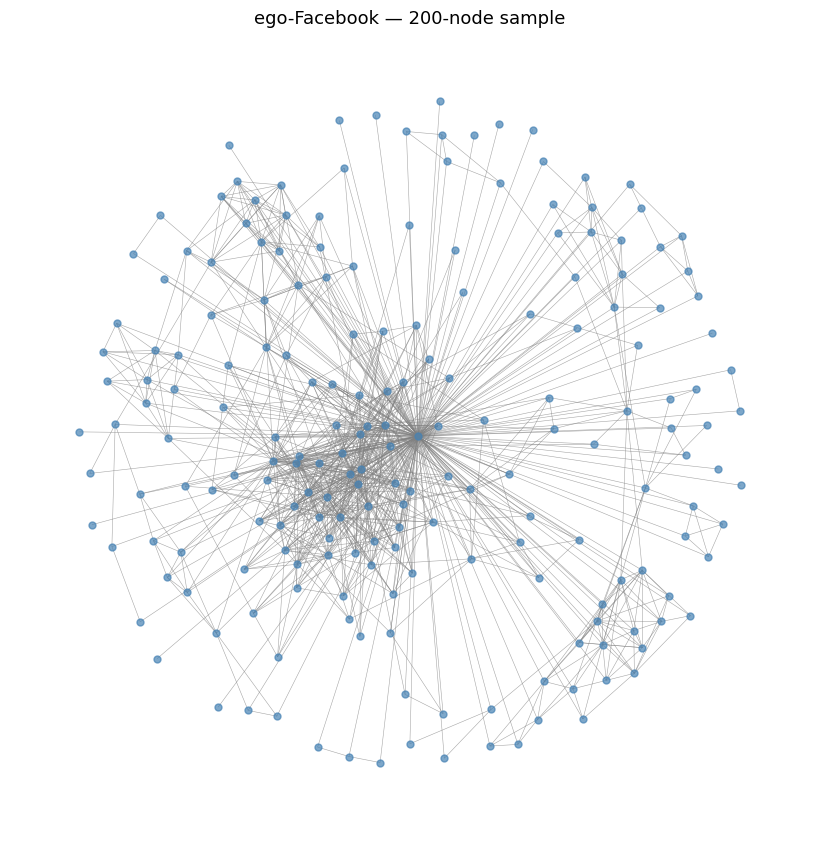

In [9]:
sample_nodes = list(G.nodes())[:200]
subG = G.subgraph(sample_nodes)

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(subG, seed=42)
nx.draw(subG, pos, node_size=25, node_color="steelblue",
        edge_color="grey", alpha=0.7, width=0.4)
plt.title("ego-Facebook — 200-node sample", fontsize=13)
plt.tight_layout()
plt.show()

##  Community Detection — SLPA (t=100, r=0.1)

In [10]:
result = algorithms.slpa(G, t=100, r=0.1)
communities_list = result.communities

node_to_coms = defaultdict(set)
for i, com in enumerate(communities_list):
    for node in com:
        node_to_coms[node].add(i)

overlapping     = {n for n, coms in node_to_coms.items() if len(coms) > 1}
non_overlapping = {n for n, coms in node_to_coms.items() if len(coms) == 1}
n_c = len(communities_list)

print(f"Communities      : {n_c}  ")
print(f"Overlapping nodes: {len(overlapping):,}  ({100*len(overlapping)/G.number_of_nodes():.1f}%)  ")
avg_m = np.mean([len(coms) for coms in node_to_coms.values()])
print(f"Avg memberships  : {avg_m:.2f}  ")

Communities      : 11  
Overlapping nodes: 6  (0.1%)  
Avg memberships  : 1.00  


##  Community Visualisation 

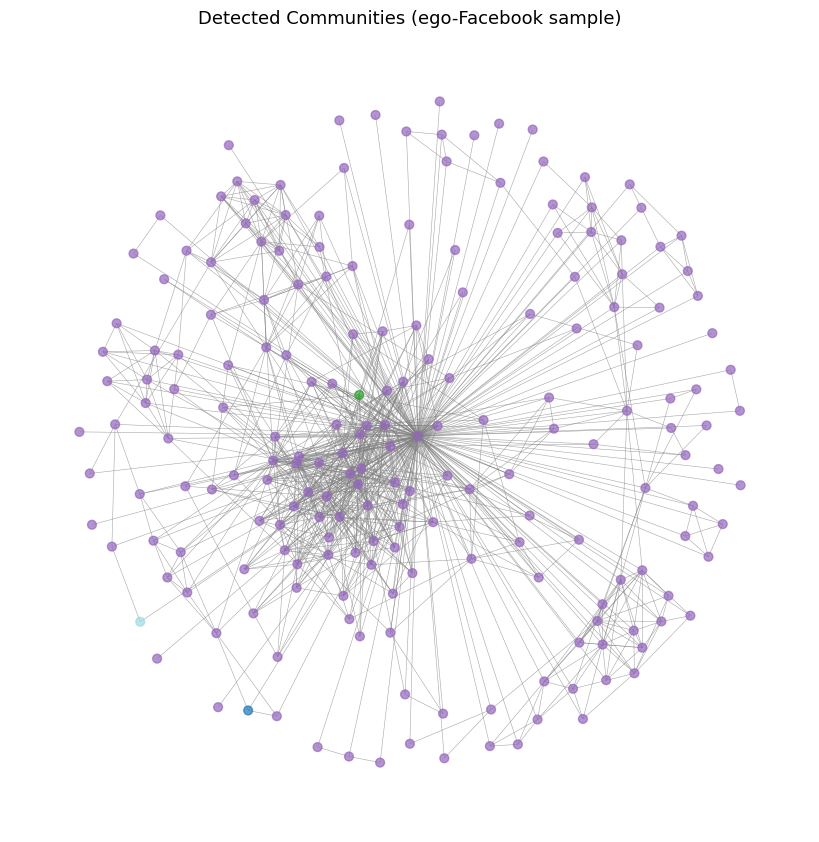

In [11]:
color_map_fixed = {node: min(coms) for node, coms in node_to_coms.items()}
colors = [color_map_fixed.get(node, 0) for node in subG.nodes()]

plt.figure(figsize=(8, 8))
nx.draw(subG, pos, node_color=colors, node_size=40,
        cmap=plt.cm.tab20, edge_color="grey", alpha=0.7, width=0.4)
plt.title("Detected Communities (ego-Facebook sample)", fontsize=13)
plt.tight_layout()
plt.show()

##  Network Decomposition — G_l and G_g

In [12]:
Gl = nx.Graph()
for i, com in enumerate(communities_list):
    com_set = set(com)
    for u in com:
        for v in G.neighbors(u):
            if v in com_set:
                Gl.add_edge((u, i), (v, i))   

print(f"Local  network — nodes: {Gl.number_of_nodes():,}  edges: {Gl.number_of_edges():,}")

Gg = nx.Graph()
Gg.add_nodes_from(G.nodes())
for u, v in G.edges():
    if not node_to_coms[u].intersection(node_to_coms[v]):
        Gg.add_edge(u, v)
Gg.remove_nodes_from(list(nx.isolates(Gg)))

print(f"Global network — nodes: {Gg.number_of_nodes():,}  edges: {Gg.number_of_edges():,}")

Local  network — nodes: 4,045  edges: 87,273
Global network — nodes: 478  edges: 962


##  Compute Overlapping Modular Centrality


In [13]:
def local_centrality(Gl, measure):
    if measure == "degree":       raw = nx.degree_centrality(Gl)
    elif measure == "betweenness": raw = nx.betweenness_centrality(Gl)
    elif measure == "closeness":   raw = nx.closeness_centrality(Gl)
    elif measure == "eigenvector":
        try:    raw = nx.eigenvector_centrality(Gl, max_iter=1000)
        except: raw = {n: 0.0 for n in Gl.nodes()}
    agg = defaultdict(float)
    for (node, cid), val in raw.items():
        agg[node] = max(agg[node], val)
    return dict(agg)

def global_centrality(Gg, measure):
    if measure == "degree":       return nx.degree_centrality(Gg)
    elif measure == "betweenness": return nx.betweenness_centrality(Gg)
    elif measure == "closeness":   return nx.closeness_centrality(Gg)
    elif measure == "eigenvector":
        try:    return nx.eigenvector_centrality(Gg, max_iter=1000)
        except: return {n: 0.0 for n in Gg.nodes()}

def compute_omc(G, Gl, Gg, measure):
    lc = local_centrality(Gl, measure)
    gc = global_centrality(Gg, measure)
    return {n: (lc.get(n, 0.0), gc.get(n, 0.0)) for n in G.nodes()}

measures = ["degree", "betweenness", "closeness", "eigenvector"]
omc_all = {}
for m in measures:
    omc_all[m] = compute_omc(G, Gl, Gg, m)
    print(f"  {m} done")
print("Done.")

  degree done
  betweenness done
  closeness done
  eigenvector done
Done.


##  Ranking Measures


In [14]:
def modulus(omc):
    return {n: math.sqrt(bL**2 + bG**2) for n, (bL, bG) in omc.items()}

def weighted_omc(G, omc, communities_list, node_to_coms, Gg, n_c):
    N = G.number_of_nodes()
    rho_cache = {}
    for i, com in enumerate(communities_list):
        com_set = set(com)
        total = sum(G.degree(v) for v in com_set)
        inter = sum(1 for v in com_set for w in G.neighbors(v) if w not in com_set)
        rho_cache[i] = inter / total if total else 0.0

    def alpha(node):
        if node not in Gg: return 0
        nbr_coms = set()
        for w in Gg.neighbors(node):
            nbr_coms.update(node_to_coms[w] - node_to_coms[node])
        return len(nbr_coms)

    scores = {}
    for node, (bL, bG) in omc.items():
        coms = node_to_coms[node]
        best = max(coms, key=lambda i: len(communities_list[i]))
        S_My = len(set(communities_list[best]))
        rho  = rho_cache[best]
        alph = alpha(node)
        scores[node] = (1 - rho) * (S_My / N) * bL + rho * (alph / max(n_c, 1)) * bG
    return scores

omc_deg      = omc_all["degree"]
modulus_deg  = modulus(omc_deg)
weighted_deg = weighted_omc(G, omc_deg, communities_list, node_to_coms, Gg, n_c)

print("Top 10 by Modulus (Degree centrality):")
print(f"{'Node':>6}  {'Type':>12}  {'Local':>8}  {'Global':>8}  {'Modulus':>8}")
print("-" * 50)
for n in sorted(modulus_deg, key=modulus_deg.get, reverse=True)[:10]:
    bL, bG = omc_deg[n]
    t = "Overlapping" if n in overlapping else "Non-overlap"
    print(f"{n:>6}  {t:>12}  {bL:>8.4f}  {bG:>8.4f}  {modulus_deg[n]:>8.4f}")

Top 10 by Modulus (Degree centrality):
  Node          Type     Local    Global   Modulus
--------------------------------------------------
   107   Non-overlap    0.2527    0.0482    0.2573
  1684   Non-overlap    0.1921    0.0314    0.1947
  1912   Non-overlap    0.1860    0.0063    0.1861
   483   Non-overlap    0.0391    0.1530    0.1579
   414   Non-overlap    0.0215    0.1509    0.1525
  3437   Non-overlap    0.1348    0.0042    0.1348
   353   Non-overlap    0.0134    0.1006    0.1015
  1718   Non-overlap    0.0272    0.0943    0.0982
   484   Non-overlap    0.0151    0.0964    0.0976
   366   Non-overlap    0.0129    0.0943    0.0952


##  SIR Epidemic Simulation

In [15]:
def sir(G, seeds, lam=0.1, gamma=0.1, max_iter=500):
    state = {v: "S" for v in G.nodes()}
    for v in seeds:
        if v in state: state[v] = "I"
    N = G.number_of_nodes()
    for _ in range(max_iter):
        infected = [v for v, s in state.items() if s == "I"]
        if not infected: break
        nxt = dict(state)
        for v in infected:
            for w in G.neighbors(v):
                if state[w] == "S" and random.random() < lam:
                    nxt[w] = "I"
            if random.random() < gamma:   
                nxt[v] = "R"
        state = nxt
    return sum(1 for s in state.values() if s == "R") / N

def evaluate(G, scores, fractions, n_runs=30, lam=0.1):
    N = G.number_of_nodes()
    ranked = sorted(scores, key=scores.get, reverse=True)
    return {f0: float(np.mean([
        sir(G, ranked[:max(1, int(f0*N))], lam=lam)
        for _ in range(n_runs)
    ])) for f0 in fractions}

fractions = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14]
lam = 0.1   

res_std      = evaluate(G, nx.degree_centrality(G),     fractions, lam=lam)
print("  Standard Degree done")
res_local    = evaluate(G, {n: omc_deg[n][0] for n in G}, fractions, lam=lam)
print("  OMC Local done")
res_global   = evaluate(G, {n: omc_deg[n][1] for n in G}, fractions, lam=lam)
print("  OMC Global done")
res_modulus  = evaluate(G, modulus_deg,  fractions, lam=lam)
print("  Modulus done")
res_weighted = evaluate(G, weighted_deg, fractions, lam=lam)
print("  Weighted OMC done")
print("Complete.")

  Standard Degree done
  OMC Local done
  OMC Global done
  Modulus done
  Weighted OMC done
Complete.


##  Δr vs f0 Plot 

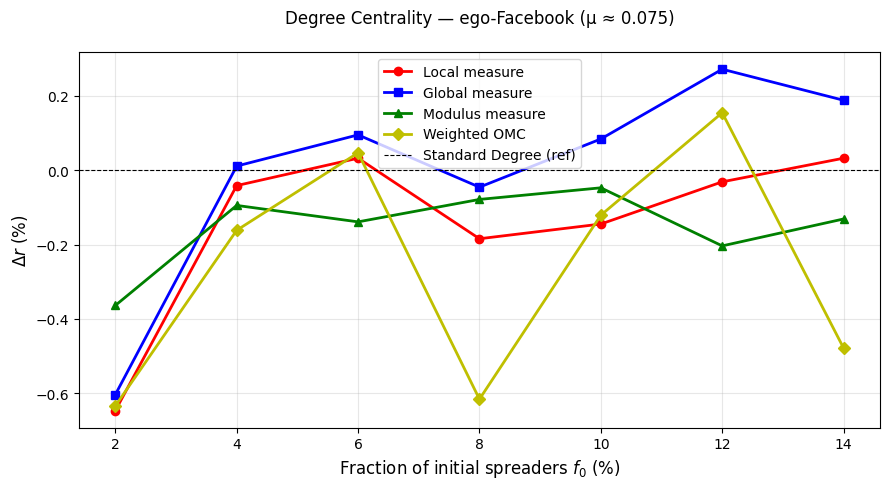

In [16]:
f0_pct   = [f * 100 for f in fractions]
std_arr  = np.array([res_std[f] for f in fractions])

def delta_r(res):
    arr = np.array([res[f] for f in fractions])
    return (arr - std_arr) / (std_arr + 1e-12) * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(f0_pct, delta_r(res_local),   "r-o",  lw=2, label="Local measure")
ax.plot(f0_pct, delta_r(res_global),  "b-s",  lw=2, label="Global measure")
ax.plot(f0_pct, delta_r(res_modulus), "g-^",  lw=2, label="Modulus measure")
ax.plot(f0_pct, delta_r(res_weighted),"y-D",  lw=2, label="Weighted OMC")
ax.axhline(0, color="black", lw=0.8, ls="--", label="Standard Degree (ref)")

ax.set_xlabel("Fraction of initial spreaders $f_0$ (%)", fontsize=12)
ax.set_ylabel(r"$\Delta r$ (%)", fontsize=12)
ax.set_title("Degree Centrality — ego-Facebook (μ ≈ 0.075)\n" , fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##  Summary Across All Four Centrality Measures

In [17]:
print(f"{'Measure':>12}  {'Top Local':>10}  {'bL':>7}  {'Top Global':>11}  {'bG':>7}  {'Top Modulus':>11}")
print("-" * 70)
for m in measures:
    omc_m = omc_all[m]
    mod_m = modulus(omc_m)
    tL = max(omc_m, key=lambda n: omc_m[n][0])
    tG = max(omc_m, key=lambda n: omc_m[n][1])
    tM = max(mod_m,  key=mod_m.get)
    print(f"{m:>12}  {tL:>10}  {omc_m[tL][0]:>7.4f}  "          f"{tG:>11}  {omc_m[tG][1]:>7.4f}  {tM:>11}")

     Measure   Top Local       bL   Top Global       bG  Top Modulus
----------------------------------------------------------------------
      degree         107   0.2527          483   0.1530          107
 betweenness         107   0.0492          107   0.5533          107
   closeness         107   0.2527          107   0.4091          107
 eigenvector        1912   0.0954          414   0.3243          414


##  Centrality Distribution

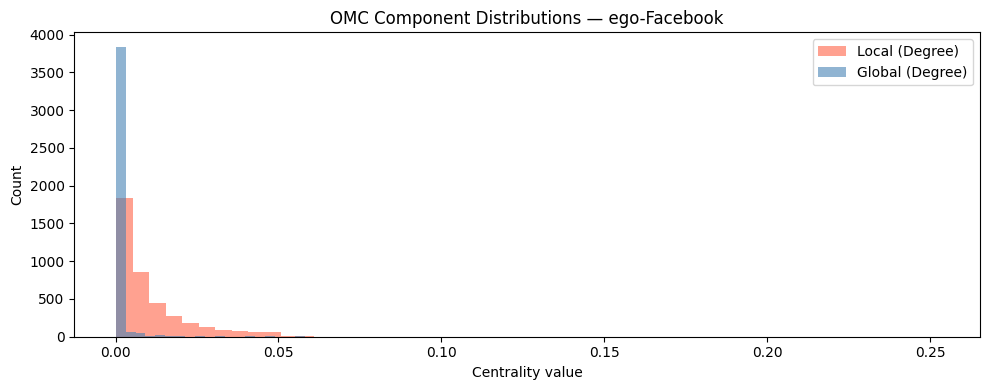

In [18]:
local_vals  = [omc_deg[n][0] for n in G.nodes()]
global_vals = [omc_deg[n][1] for n in G.nodes()]

plt.figure(figsize=(10, 4))
plt.hist(local_vals,  bins=50, alpha=0.6, label="Local (Degree)",  color="tomato")
plt.hist(global_vals, bins=50, alpha=0.6, label="Global (Degree)", color="steelblue")
plt.xlabel("Centrality value"); plt.ylabel("Count")
plt.title("OMC Component Distributions — ego-Facebook")
plt.legend(); plt.tight_layout(); plt.show()

##  Top-10 Influential Nodes (by Modulus)

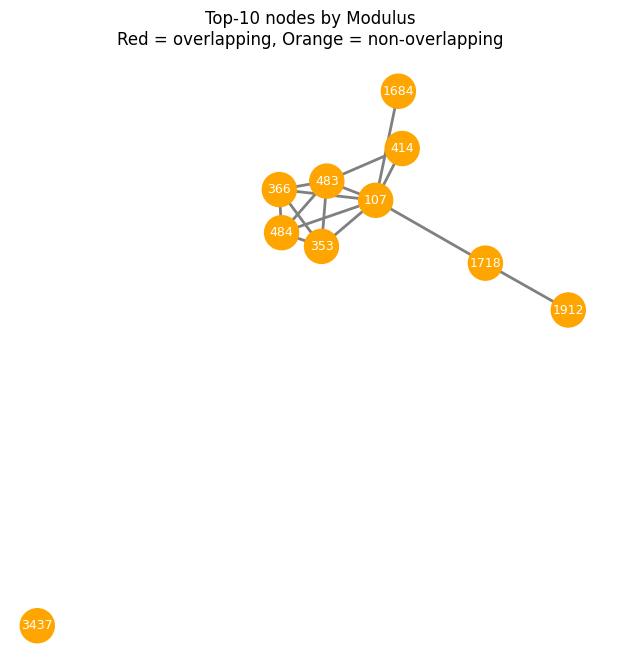

In [19]:
top10 = sorted(modulus_deg, key=modulus_deg.get, reverse=True)[:10]
sub   = G.subgraph(top10)

color = ["red" if n in overlapping else "orange" for n in sub.nodes()]
plt.figure(figsize=(6, 6))
nx.draw(sub, with_labels=True, node_color=color,
        node_size=600, font_size=9, font_color="white",
        edge_color="grey", width=2)
plt.title("Top-10 nodes by Modulus\nRed = overlapping, Orange = non-overlapping")
plt.tight_layout(); plt.show()